In [1]:
import numpy as np
import matplotlib.pyplot as plt
from deepOnet_definitions import *
from FFEM_building_blocks import Mesh


In [2]:
# automatic generation of source functions and the Poisson solution algorithm

def generate_source_function(num_modes:int=3, max_freq:int=4, max_amplitude = 1.):
    """
    Uses a random truncated Fourier series with random amplitudes
    """
    # first pick some frequencies
    kx = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)
    ky = np.random.randint(-max_freq-1, max_freq + 1, size=num_modes)

    # now draw the corresponding amplitudes and phases
    amplitudes = np.random.uniform(-max_amplitude, max_amplitude, size=num_modes)
    phases = np.random.uniform(0, 2 * np.pi, size=num_modes)

    def source_function(x, y):
        result = 0
        for i in range(num_modes):
            result += amplitudes[i] * np.cos(kx[i] * x + ky[i] * y + phases[i])
        return result

    return source_function

In [3]:
x_branch = np.linspace(-1, 1, 20)
y_branch = np.linspace(-1, 1, 20)
X_branch, Y_branch = np.meshgrid(x_branch, y_branch, indexing="ij")
coords_branch = np.stack([X_branch.ravel(), Y_branch.ravel()], axis=-1)


don = deepOnet_v1(x_coords_for_branch = coords_branch, N_nodes_branch = 200, N_nodes_trunk = 200, latent_dimension = 200)

don.fit_from_npz('data/dataset.npz', 16000)

Y std across samples: 0.04507255181670189
Y std across points: 0.036380499601364136
Epoch [100/16000], Loss: 0.0155, Loss eval: 0.0154
prediction std across samples: 0.047222256660461426
prediction std across points: 0.09672663360834122
Epoch [200/16000], Loss: 0.0064, Loss eval: 0.0063
prediction std across samples: 0.035117413848638535
prediction std across points: 0.05190267786383629
Epoch [300/16000], Loss: 0.0050, Loss eval: 0.0049
prediction std across samples: 0.029436003416776657
prediction std across points: 0.04087832570075989
Epoch [400/16000], Loss: 0.0043, Loss eval: 0.0043
prediction std across samples: 0.025601722300052643
prediction std across points: 0.03413347899913788
Epoch [500/16000], Loss: 0.0039, Loss eval: 0.0039
prediction std across samples: 0.022720888257026672
prediction std across points: 0.029449963942170143
Epoch [600/16000], Loss: 0.0037, Loss eval: 0.0036
prediction std across samples: 0.02046208642423153
prediction std across points: 0.0259621310979127

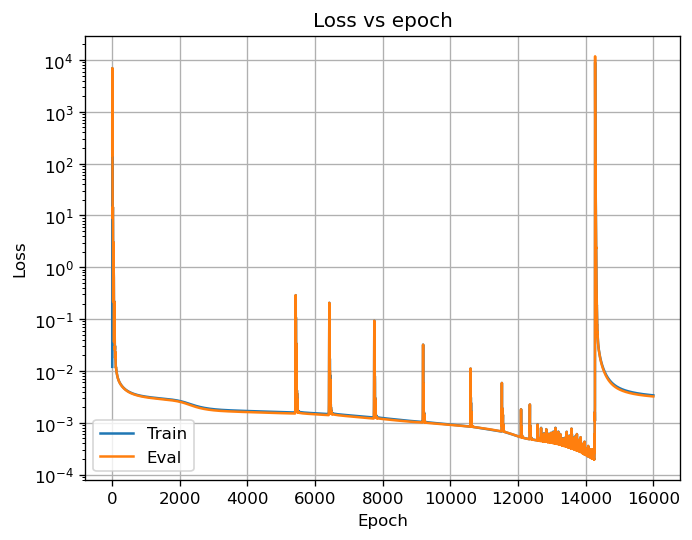

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_61156/247360811.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


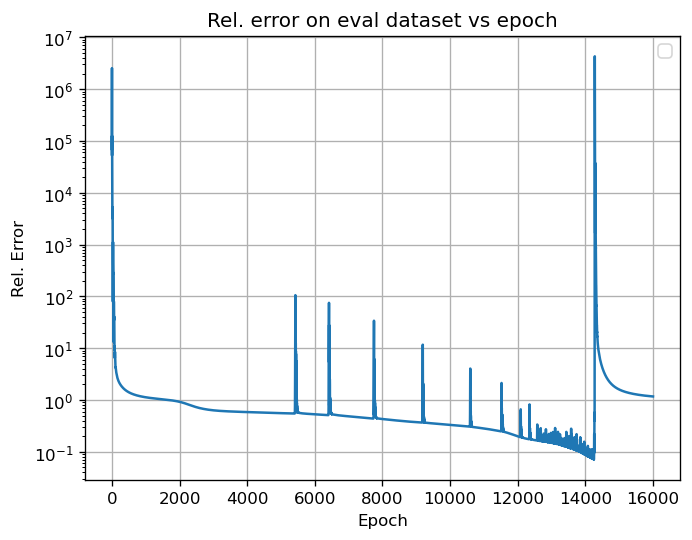

In [4]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(don.epochs, don.losses, label = "Train")
plt.semilogy(don.epochs, don.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(don.epochs, don.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

Mass matrix initialization completed
Stiffness matrix initialization completed


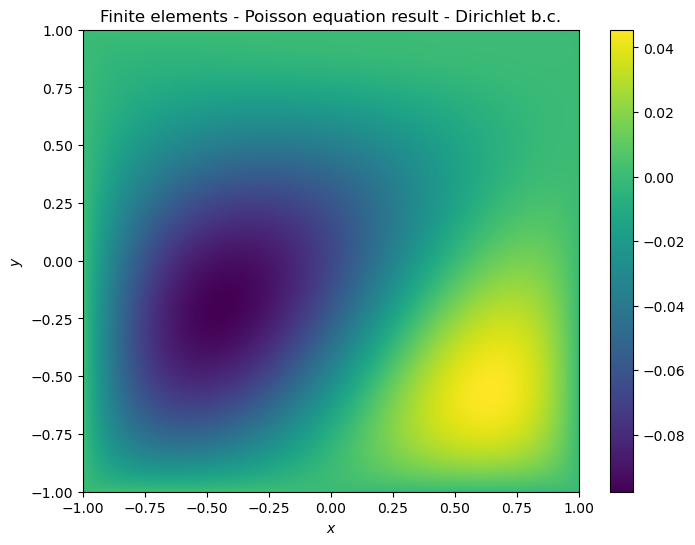

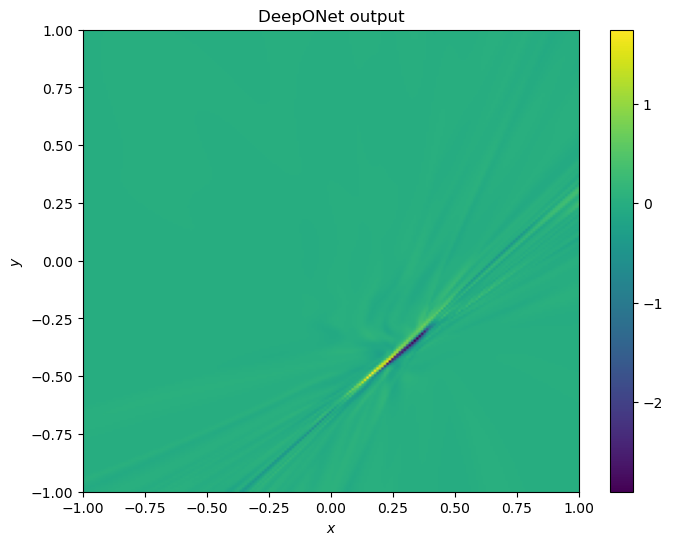

In [5]:
# now test visually on a randomly generated function

x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()
# coordinates of mesh points 
X, Y = np.meshgrid(x, y, indexing="ij")
coords = np.stack([X.ravel(), Y.ravel()], axis=-1)
diri = lambda x, y: 0

func = generate_source_function()
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)
plt.figure(figsize=(8, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


result_don = don.map_function_to_output_at_points(func, np.array(coords)).squeeze(0).detach().numpy().reshape(200,200)
# detach to get rid of the tensor structure
# squeeze(0) to go from dimension (1, N) to (N)


plt.figure(figsize=(8, 6))
plt.imshow(result_don, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('DeepONet output')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

In [6]:
# TO DO: more quantitative tests on a control dataset

# TO DO: try GRF for lower effective dimensionality

**The code now runs, but the results are not that good**
In particular; the relative error on the eval dataset plateaus to 1. this is due to the fact that the output is basically identical for all points in the domain. Issue with the trunk sector?

more work needs to be done since from the plots above one can clearly see that the results do not match. Reduce dimensionaly ? (GRF)

https://arxiv.org/pdf/2509.12344.  (Fourier features)


explodes after around 16500 epochs